<a href="https://colab.research.google.com/github/Bhavyaa16/Celebel-excelence-internship-assignments/blob/main/week3_bhavya_chauthramani.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Intelligence System
### Classification | Ensemble Learning | Clustering

**Dataset:** Country-level socio-economic and health data  
**Goal:** Segment countries based on development indicators and build predictive models to classify need for aid

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import kagglehub
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    silhouette_score, roc_auc_score, roc_curve
)
from sklearn.decomposition import PCA
from xgboost import XGBClassifier

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
sns.set_palette('Set2')

## 1. Data Loading & Initial Exploration

In [5]:
path = kagglehub.dataset_download("rohan0301/unsupervised-learning-on-country-data")

from google.colab import files
uploaded = files.upload()
import io
path = io.BytesIO(list(uploaded.values())[0])

df = pd.read_csv(path)
print(df.shape)
df.head(8)



df = pd.read_csv('Country-data.csv')
print(df.shape)
df.head(8)

100%|██████████| 5.21k/5.21k [00:00<00:00, 3.60MB/s]

Extracting files...


Saving Country-data.csv to Country-data.csv
(167, 10)
(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.90,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.77,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.16,82.0,1.93,51900


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [8]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


## 2. Exploratory Data Analysis

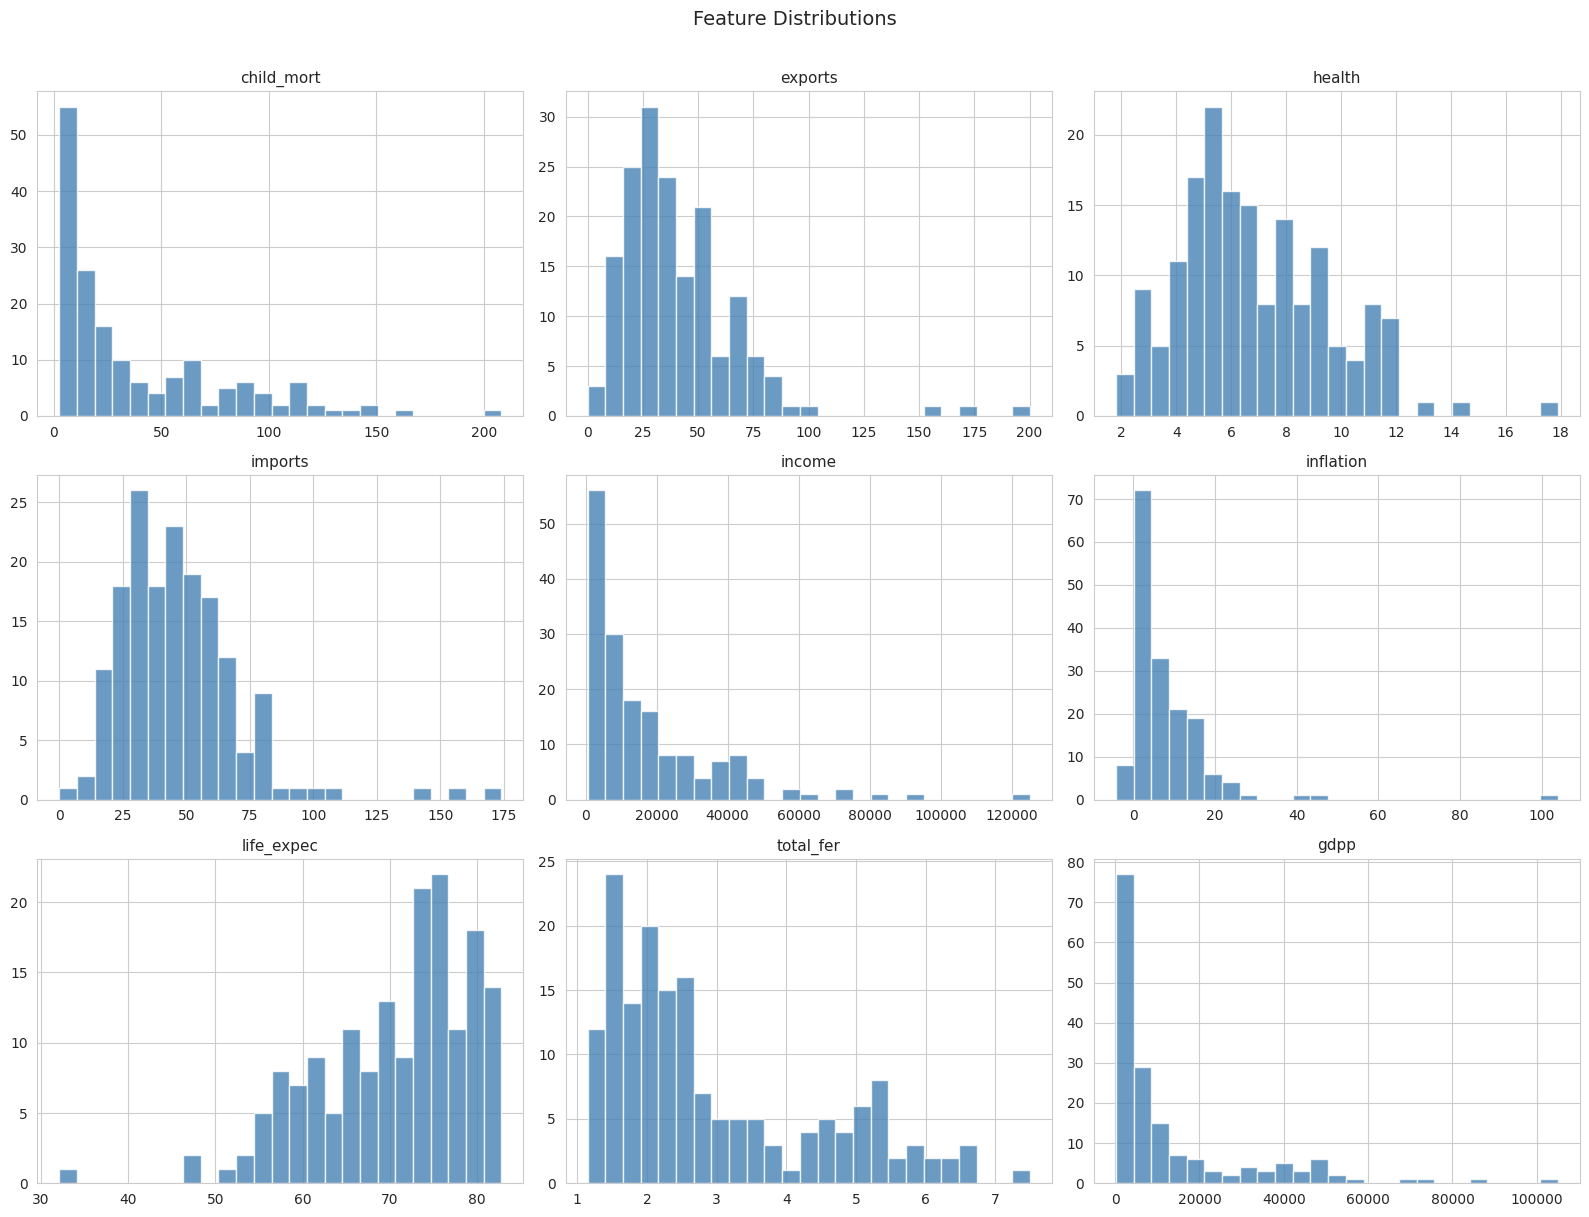

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

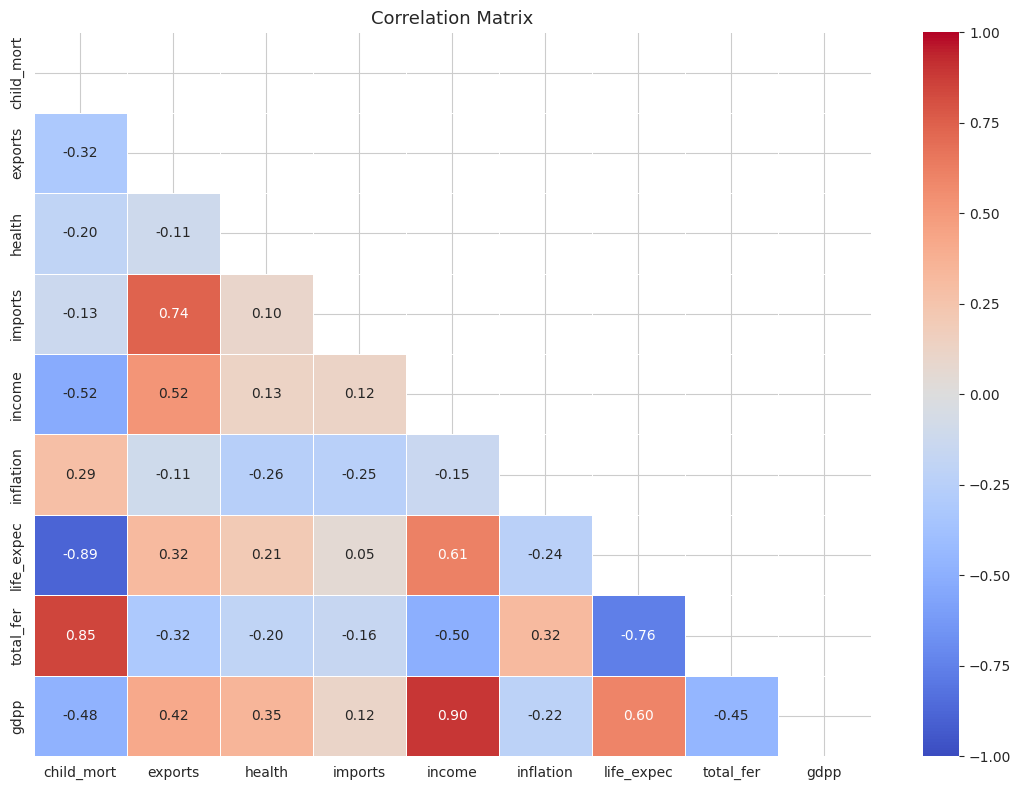

In [10]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

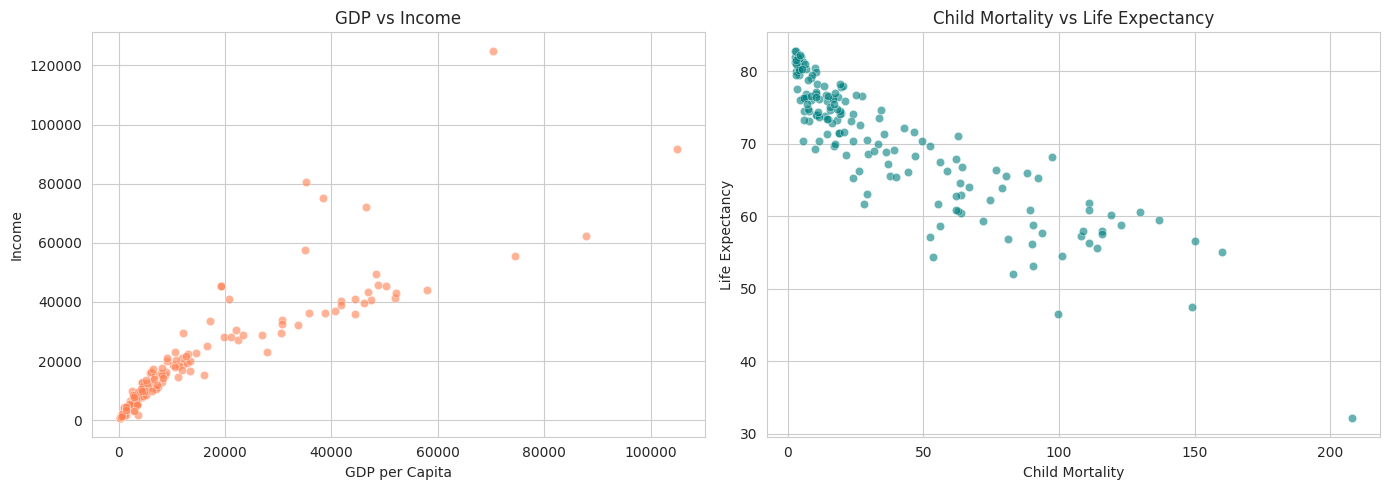

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['gdpp'], df['income'], alpha=0.6, color='coral', edgecolors='white', linewidth=0.4)
axes[0].set_xlabel('GDP per Capita')
axes[0].set_ylabel('Income')
axes[0].set_title('GDP vs Income')

axes[1].scatter(df['child_mort'], df['life_expec'], alpha=0.6, color='teal', edgecolors='white', linewidth=0.4)
axes[1].set_xlabel('Child Mortality')
axes[1].set_ylabel('Life Expectancy')
axes[1].set_title('Child Mortality vs Life Expectancy')

plt.tight_layout()
plt.show()

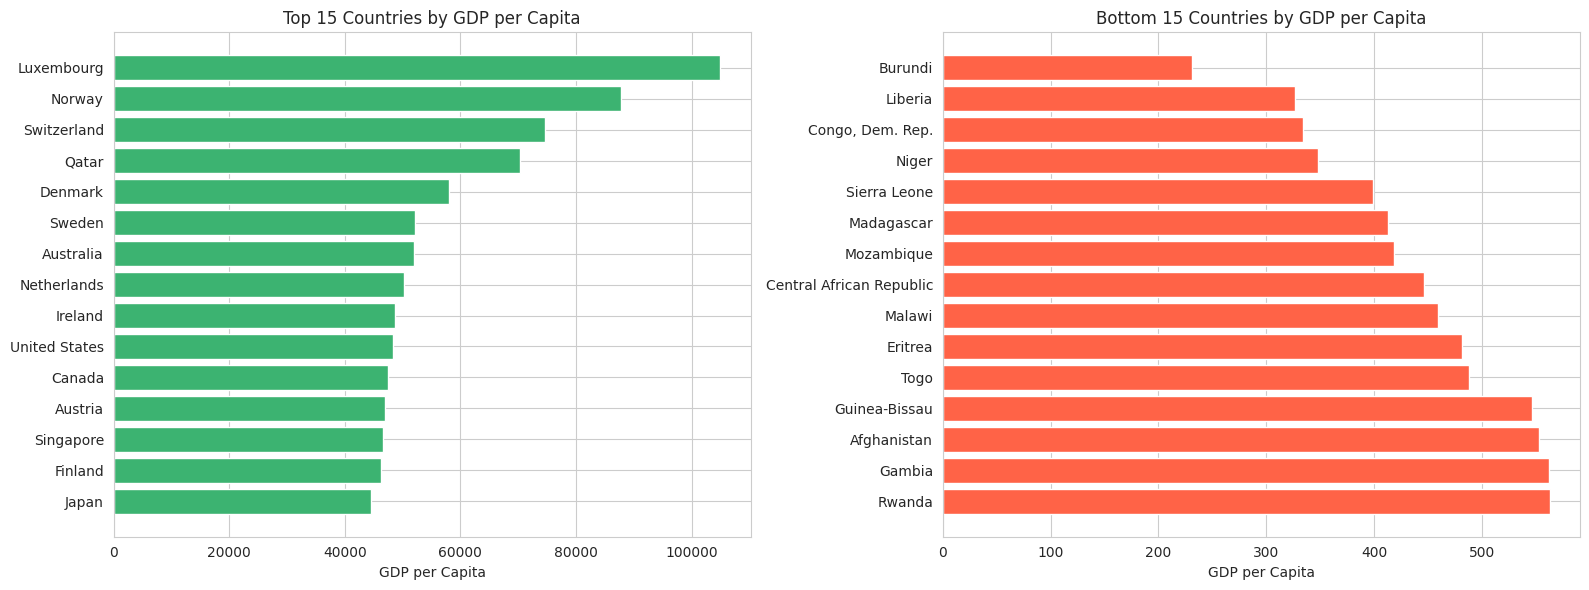

In [12]:
top_gdp = df.nlargest(15, 'gdpp')[['country', 'gdpp']]
bot_gdp = df.nsmallest(15, 'gdpp')[['country', 'gdpp']]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_gdp['country'], top_gdp['gdpp'], color='mediumseagreen')
axes[0].set_title('Top 15 Countries by GDP per Capita')
axes[0].set_xlabel('GDP per Capita')
axes[0].invert_yaxis()

axes[1].barh(bot_gdp['country'], bot_gdp['gdpp'], color='tomato')
axes[1].set_title('Bottom 15 Countries by GDP per Capita')
axes[1].set_xlabel('GDP per Capita')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3. Feature Engineering & Target Variable Creation

In [13]:
df['development_score'] = (
    (df['life_expec'] / df['life_expec'].max()) * 0.3 +
    (df['gdpp'] / df['gdpp'].max()) * 0.4 +
    (df['income'] / df['income'].max()) * 0.2 +
    (1 - df['child_mort'] / df['child_mort'].max()) * 0.1
)

q33 = df['development_score'].quantile(0.33)
q66 = df['development_score'].quantile(0.66)

def label_country(score):
    if score < q33:
        return 0
    elif score < q66:
        return 1
    else:
        return 2

df['dev_category'] = df['development_score'].apply(label_country)

label_map = {0: 'Underdeveloped', 1: 'Developing', 2: 'Developed'}
df['dev_label'] = df['dev_category'].map(label_map)

print(df['dev_label'].value_counts())
print()
df[['country', 'gdpp', 'life_expec', 'development_score', 'dev_label']].head(10)

dev_label
Developed         57
Underdeveloped    55
Developing        55
Name: count, dtype: int64



,country,gdpp,life_expec,development_score,dev_label
0,Afghanistan,553,56.2,0.264940,Underdeveloped
1,Albania,4090,76.3,0.399937,Developing
2,Algeria,4460,76.5,0.401679,Developing
3,Angola,3530,60.1,0.283430,Underdeveloped
4,Antigua and Barbuda,12200,76.8,0.450345,Developed
5,Argentina,10300,75.8,0.436825,Developed
6,Armenia,3220,73.3,0.379864,Developing
7,Australia,51900,82.0,0.658748,Developed
8,Austria,46900,80.5,0.637386,Developed
9,Azerbaijan,5840,69.1,0.379364,Developing


In [14]:
df['gdpp_log'] = np.log1p(df['gdpp'])
df['income_log'] = np.log1p(df['income'])
df['imports_log'] = np.log1p(df['imports'])
df['exports_log'] = np.log1p(df['exports'])

df['trade_balance'] = df['exports'] - df['imports']
df['health_per_income'] = df['health'] / (df['income'] + 1)

df.head(3)

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,development_score,dev_category,dev_label,gdpp_log,income_log,imports_log,exports_log,trade_balance,health_per_income
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0.264940,0,Underdeveloped,6.317165,7.384610,3.826465,2.397895,-34.9,0.004705
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0.399937,1,Developing,8.316545,9.203416,3.903991,3.367296,-20.6,0.000660
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0.401679,1,Developing,8.403128,9.465060,3.478158,3.673766,7.0,0.000323


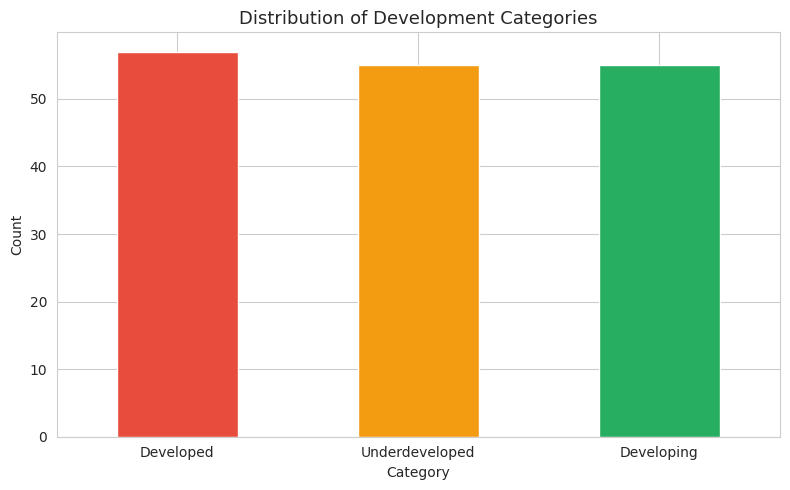

In [15]:
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#27ae60']
df['dev_label'].value_counts().plot(kind='bar', color=colors, edgecolor='white')
plt.title('Distribution of Development Categories', fontsize=13)
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [16]:
feature_cols = [
    'child_mort', 'exports', 'health', 'imports', 'income',
    'inflation', 'life_expec', 'total_fer', 'gdpp',
    'gdpp_log', 'income_log', 'trade_balance', 'health_per_income'
]

X = df[feature_cols].copy()
y = df['dev_category'].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.22, random_state=42, stratify=y
)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size:  {X_test.shape[0]}')

Train size: 130
Test size:  37


## 5. Baseline Classification Models

In [17]:
dt = DecisionTreeClassifier(max_depth=6, random_state=7)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

lr = LogisticRegression(max_iter=500, random_state=7)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Decision Tree Accuracy:', round(accuracy_score(y_test, y_pred_dt), 4))
print('Logistic Regression Accuracy:', round(accuracy_score(y_test, y_pred_lr), 4))

Decision Tree Accuracy: 0.9459
Logistic Regression Accuracy: 0.9189


In [18]:
print('Decision Tree:')
print(classification_report(y_test, y_pred_dt, target_names=list(label_map.values())))

print('\nLogistic Regression:')
print(classification_report(y_test, y_pred_lr, target_names=list(label_map.values())))

Decision Tree:
                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.86      1.00      0.92        12
     Developed       1.00      0.92      0.96        13

      accuracy                           0.95        37
     macro avg       0.95      0.95      0.95        37
  weighted avg       0.95      0.95      0.95        37


Logistic Regression:
                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.80      1.00      0.89        12
     Developed       1.00      0.85      0.92        13

      accuracy                           0.92        37
     macro avg       0.93      0.92      0.92        37
  weighted avg       0.94      0.92      0.92        37



## 6. Ensemble Methods — Random Forest

In [19]:
rf = RandomForestClassifier(n_estimators=120, max_depth=8, min_samples_split=4,
                             min_samples_leaf=2, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Accuracy:', round(accuracy_score(y_test, y_pred_rf), 4))
print()
print(classification_report(y_test, y_pred_rf, target_names=list(label_map.values())))

Random Forest Accuracy: 0.9189

                precision    recall  f1-score   support

Underdeveloped       1.00      0.83      0.91        12
    Developing       0.80      1.00      0.89        12
     Developed       1.00      0.92      0.96        13

      accuracy                           0.92        37
     macro avg       0.93      0.92      0.92        37
  weighted avg       0.94      0.92      0.92        37



In [20]:
cv_scores_rf = cross_val_score(rf, X_scaled, y, cv=5, scoring='accuracy')
print(f'RF Cross-Val Scores: {np.round(cv_scores_rf, 3)}')
print(f'Mean: {cv_scores_rf.mean():.3f} | Std: {cv_scores_rf.std():.3f}')

RF Cross-Val Scores: [0.912 0.912 0.97  0.909 0.939]
Mean: 0.928 | Std: 0.023


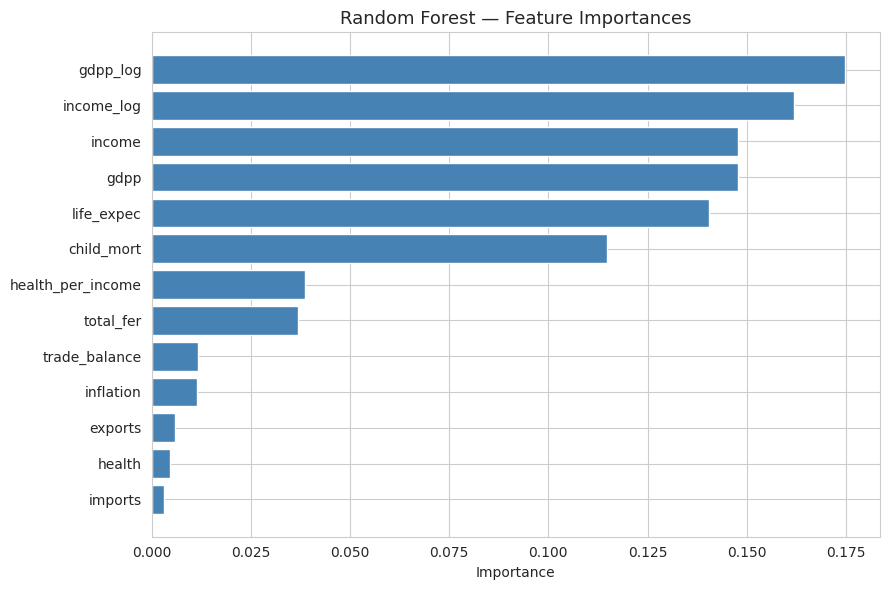

In [21]:
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importances', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## 7. Ensemble Methods — XGBoost

In [22]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print('XGBoost Accuracy:', round(accuracy_score(y_test, y_pred_xgb), 4))
print()
print(classification_report(y_test, y_pred_xgb, target_names=list(label_map.values())))

XGBoost Accuracy: 0.9459

                precision    recall  f1-score   support

Underdeveloped       1.00      0.92      0.96        12
    Developing       0.86      1.00      0.92        12
     Developed       1.00      0.92      0.96        13

      accuracy                           0.95        37
     macro avg       0.95      0.95      0.95        37
  weighted avg       0.95      0.95      0.95        37



In [23]:
cv_scores_xgb = cross_val_score(xgb, X_scaled, y, cv=5, scoring='accuracy')
print(f'XGB Cross-Val Scores: {np.round(cv_scores_xgb, 3)}')
print(f'Mean: {cv_scores_xgb.mean():.3f} | Std: {cv_scores_xgb.std():.3f}')

XGB Cross-Val Scores: [0.912 0.941 0.97  0.909 0.97 ]
Mean: 0.940 | Std: 0.027


## 8. Gradient Boosting & Hyperparameter Tuning

In [24]:
param_grid = {
    'n_estimators': [80, 120],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

gb_base = GradientBoostingClassifier(random_state=42)
grid_search = GridSearchCV(gb_base, param_grid, cv=4, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print('Best Params:', grid_search.best_params_)
print('Best CV Score:', round(grid_search.best_score_, 4))

Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 80}
Best CV Score: 0.8767


In [25]:
best_gb = grid_search.best_estimator_
y_pred_gb = best_gb.predict(X_test)

print('Gradient Boosting Test Accuracy:', round(accuracy_score(y_test, y_pred_gb), 4))
print()
print(classification_report(y_test, y_pred_gb, target_names=list(label_map.values())))

Gradient Boosting Test Accuracy: 0.8919

                precision    recall  f1-score   support

Underdeveloped       0.91      0.83      0.87        12
    Developing       0.79      0.92      0.85        12
     Developed       1.00      0.92      0.96        13

      accuracy                           0.89        37
     macro avg       0.90      0.89      0.89        37
  weighted avg       0.90      0.89      0.89        37



## 9. Model Comparison

In [26]:
model_results = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_gb)
    ]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

model_results['Accuracy'] = model_results['Accuracy'].round(4)
model_results

,Model,Accuracy
0,Decision Tree,0.9459
1,XGBoost,0.9459
2,Logistic Regression,0.9189
3,Random Forest,0.9189
4,Gradient Boosting,0.8919


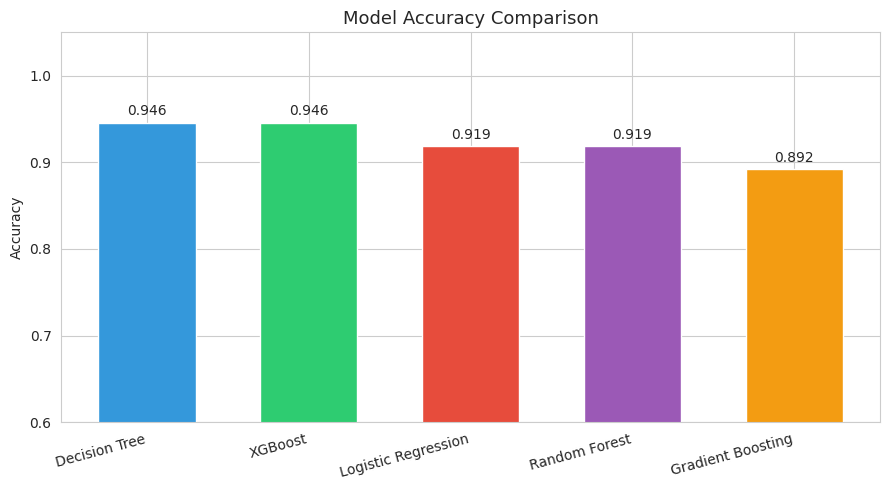

In [27]:
plt.figure(figsize=(9, 5))
bars = plt.bar(model_results['Model'], model_results['Accuracy'],
               color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12'],
               edgecolor='white', width=0.6)

for bar, val in zip(bars, model_results['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.title('Model Accuracy Comparison', fontsize=13)
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.05)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

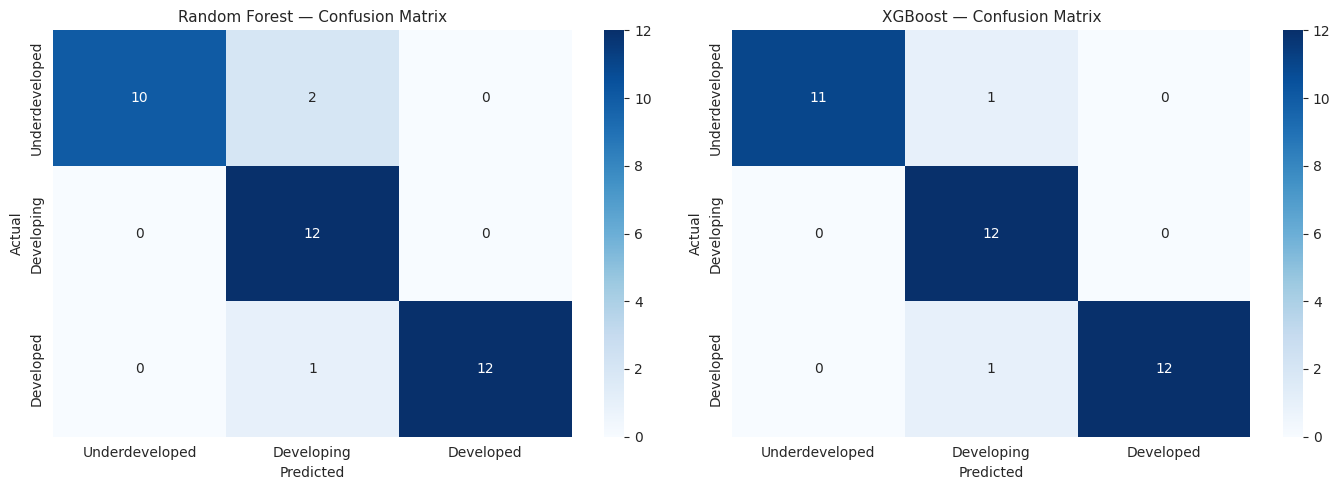

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_to_plot = [
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for ax, (name, preds) in zip(axes, models_to_plot):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=list(label_map.values()),
                yticklabels=list(label_map.values()))
    ax.set_title(f'{name} — Confusion Matrix', fontsize=11)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## 10. Clustering — K-Means

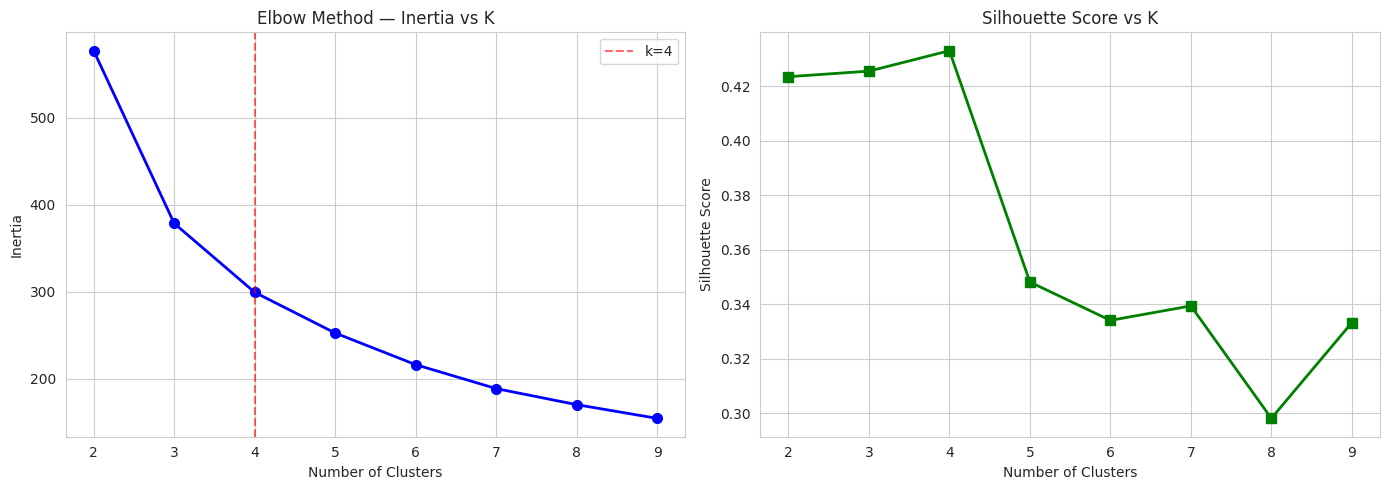

In [29]:
cluster_features = ['child_mort', 'income', 'gdpp', 'life_expec', 'inflation', 'total_fer']
X_cluster = df[cluster_features].copy()

scaler2 = StandardScaler()
X_cluster_scaled = scaler2.fit_transform(X_cluster)

inertia = []
sil_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertia, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Method — Inertia vs K', fontsize=12)
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Inertia')
axes[0].axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4')
axes[0].legend()

axes[1].plot(list(k_range), sil_scores, 'gs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score vs K', fontsize=12)
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [30]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_cluster_scaled)

print('Silhouette Score (K=4):', round(silhouette_score(X_cluster_scaled, df['kmeans_cluster']), 4))
print()
print('Cluster Sizes:')
print(df['kmeans_cluster'].value_counts().sort_index())

Silhouette Score (K=4): 0.433

Cluster Sizes:
kmeans_cluster
0    36
1    83
2    47
3     1
Name: count, dtype: int64


In [31]:
cluster_profile = df.groupby('kmeans_cluster')[cluster_features + ['gdpp']].mean().round(2)
cluster_profile

,child_mort,income,gdpp,life_expec,inflation,total_fer,gdpp
kmeans_cluster,,,,,,,
0,5.47,46705.56,42555.56,80.08,3.61,1.83,42555.56
1,21.65,11984.22,6522.55,72.97,7.20,2.25,6522.55
2,90.79,3870.70,1900.26,59.21,9.95,4.97,1900.26
3,130.00,5150.00,2330.00,60.50,104.00,5.84,2330.00


Variance Explained: PC1=62.39%, PC2=16.88%


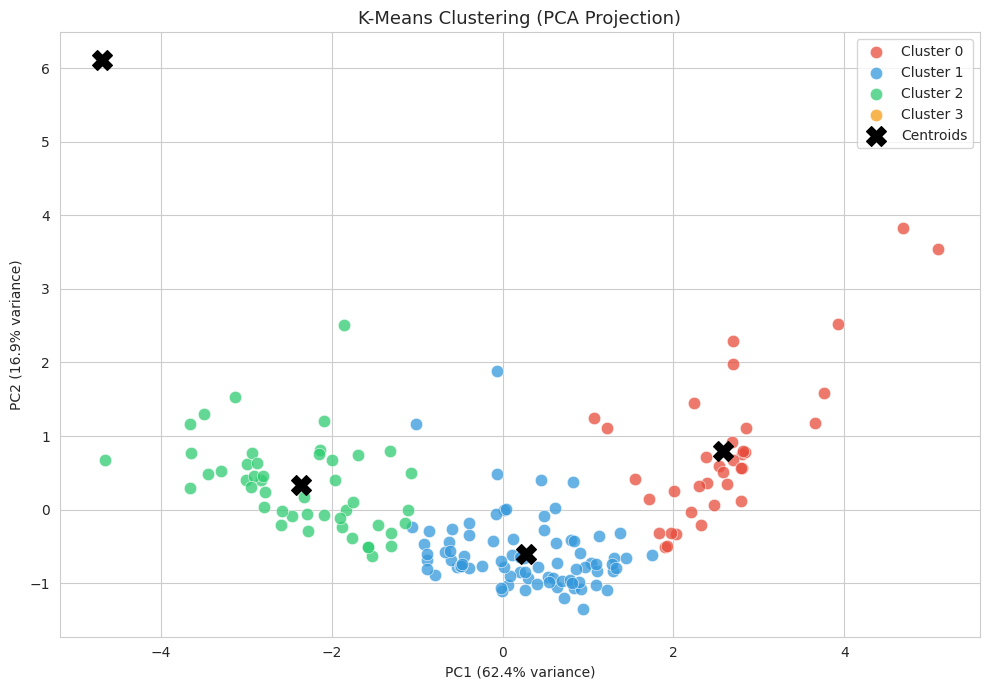

In [32]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_cluster_scaled)

df['pca1'] = pca_coords[:, 0]
df['pca2'] = pca_coords[:, 1]

print(f'Variance Explained: PC1={pca.explained_variance_ratio_[0]:.2%}, PC2={pca.explained_variance_ratio_[1]:.2%}')

plt.figure(figsize=(10, 7))
colors_cl = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for cl in sorted(df['kmeans_cluster'].unique()):
    mask = df['kmeans_cluster'] == cl
    plt.scatter(df.loc[mask, 'pca1'], df.loc[mask, 'pca2'],
                label=cluster_names[cl], alpha=0.75, s=80,
                color=colors_cl[cl], edgecolors='white', linewidth=0.5)

centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=200, c='black',
            marker='X', zorder=10, label='Centroids')

plt.title('K-Means Clustering (PCA Projection)', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.legend()
plt.tight_layout()
plt.show()

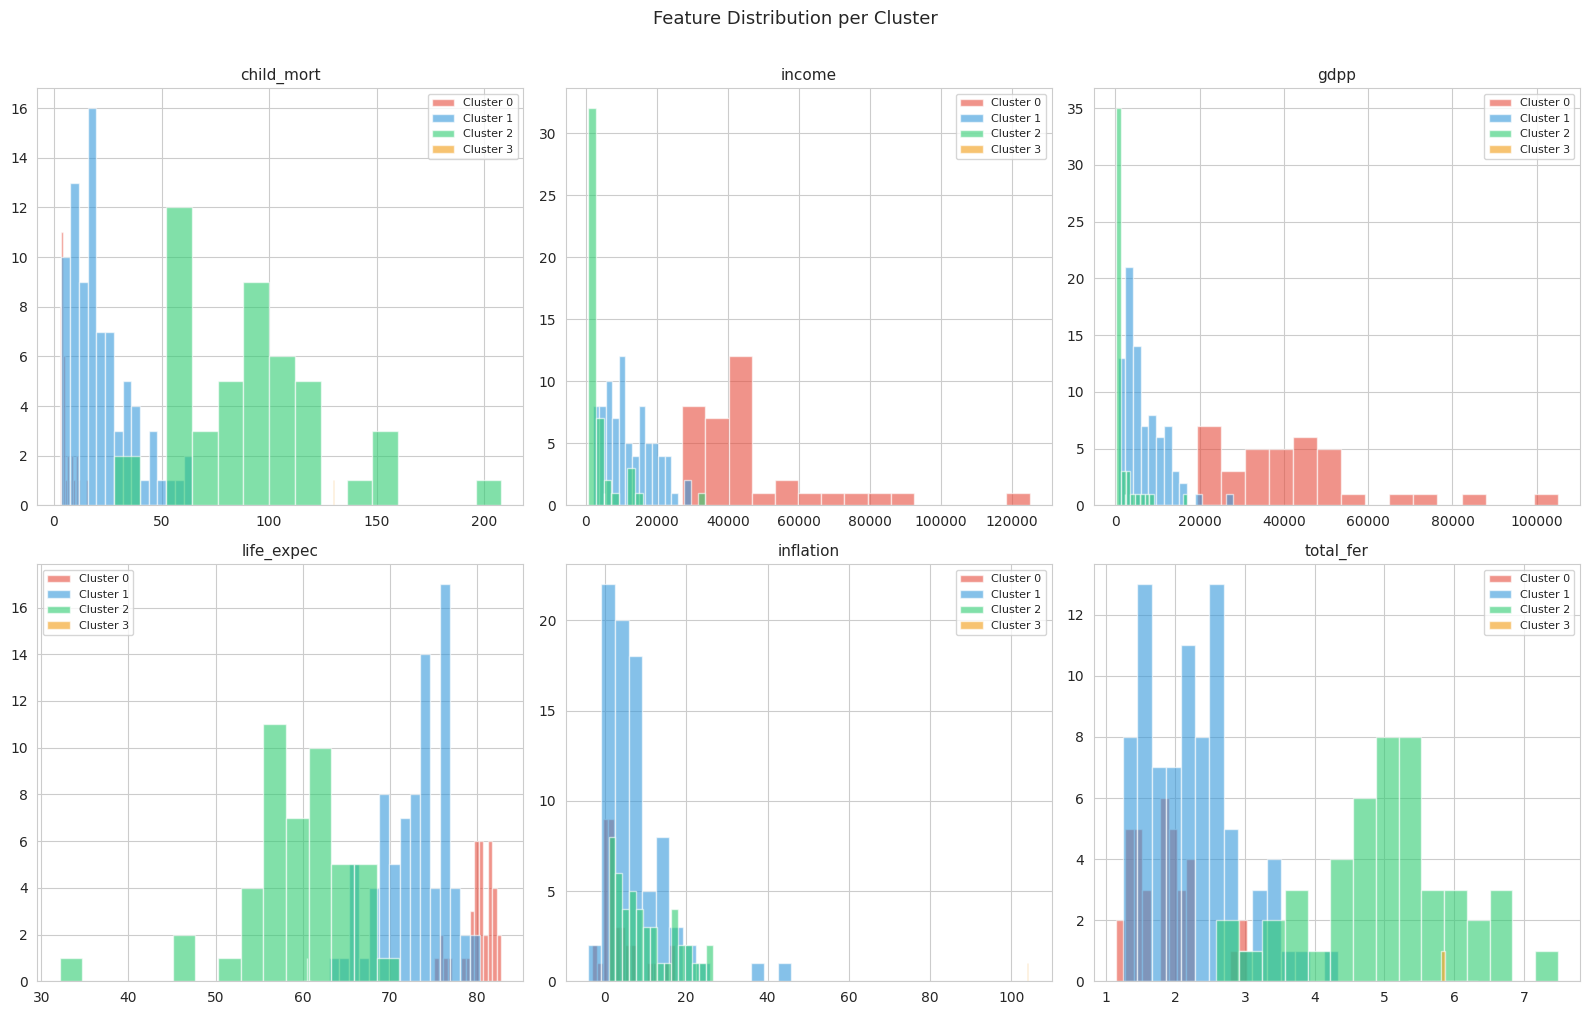

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cluster_features):
    for cl in sorted(df['kmeans_cluster'].unique()):
        mask = df['kmeans_cluster'] == cl
        axes[i].hist(df.loc[mask, feat], bins=15, alpha=0.6,
                     label=f'Cluster {cl}', color=colors_cl[cl])
    axes[i].set_title(feat, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Feature Distribution per Cluster', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 11. Clustering — DBSCAN

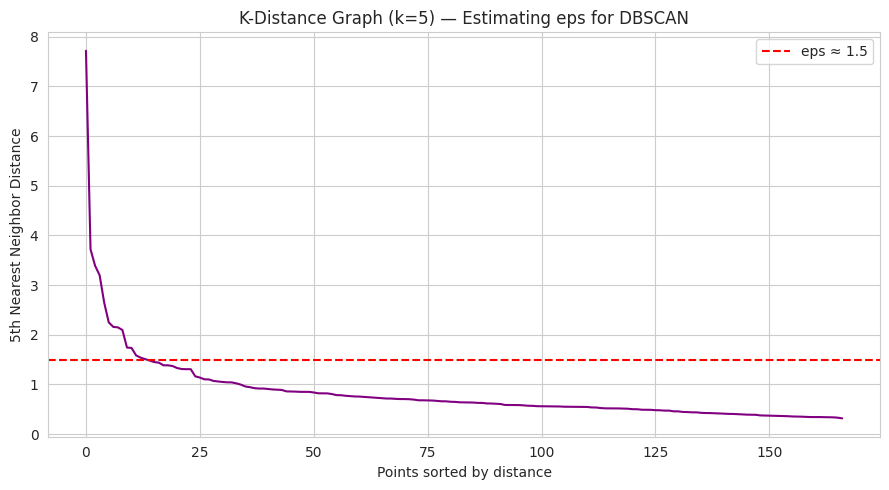

In [34]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_cluster_scaled)
distances, _ = nn.kneighbors(X_cluster_scaled)
k_distances = np.sort(distances[:, 4])[::-1]

plt.figure(figsize=(9, 5))
plt.plot(k_distances, color='purple')
plt.title('K-Distance Graph (k=5) — Estimating eps for DBSCAN', fontsize=12)
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps ≈ 1.5')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_cluster_scaled)

n_clusters = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise = (df['dbscan_cluster'] == -1).sum()

print(f'Number of clusters found: {n_clusters}')
print(f'Noise points: {n_noise}')
print()
print(df['dbscan_cluster'].value_counts())

Number of clusters found: 1
Noise points: 8

dbscan_cluster
 0    159
-1      8
Name: count, dtype: int64


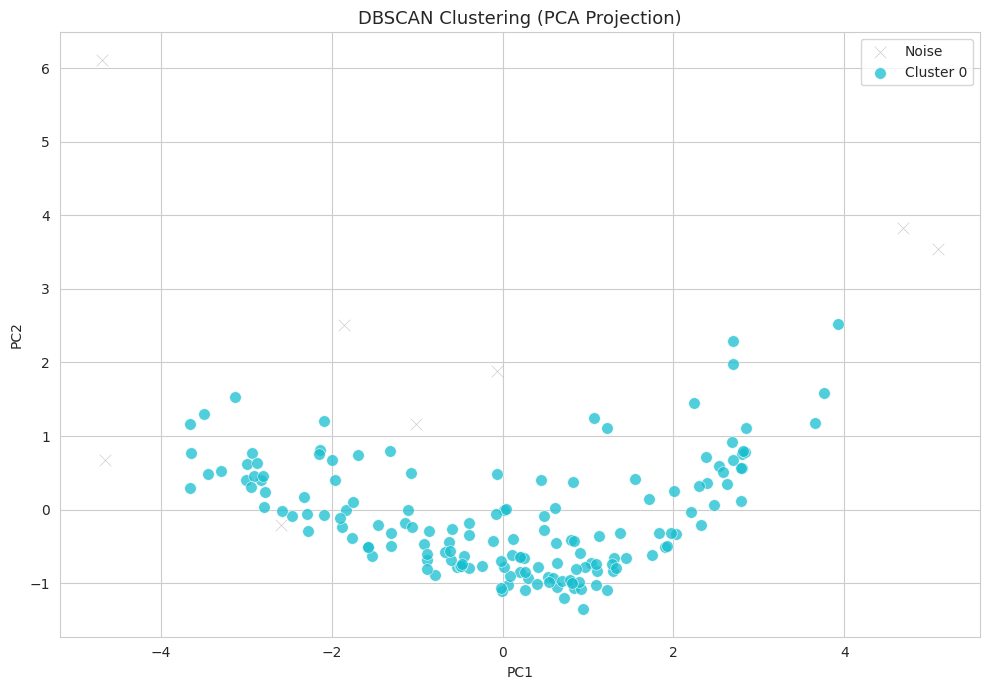

In [36]:
plt.figure(figsize=(10, 7))

unique_labels = sorted(df['dbscan_cluster'].unique())
cmap = plt.cm.get_cmap('tab10', len(unique_labels))

for idx, cl in enumerate(unique_labels):
    mask = df['dbscan_cluster'] == cl
    label = f'Noise' if cl == -1 else f'Cluster {cl}'
    color = 'grey' if cl == -1 else cmap(idx)
    alpha = 0.4 if cl == -1 else 0.75
    marker = 'x' if cl == -1 else 'o'
    plt.scatter(df.loc[mask, 'pca1'], df.loc[mask, 'pca2'],
                label=label, alpha=alpha, s=70, color=color,
                marker=marker, edgecolors='white' if cl != -1 else 'none',
                linewidth=0.5)

plt.title('DBSCAN Clustering (PCA Projection)', fontsize=13)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.tight_layout()
plt.show()

## 12. Customer Segmentation Insights

In [37]:
segment_analysis = df.groupby('kmeans_cluster').agg(
    count=('country', 'count'),
    avg_gdp=('gdpp', 'mean'),
    avg_income=('income', 'mean'),
    avg_life_exp=('life_expec', 'mean'),
    avg_child_mort=('child_mort', 'mean'),
    avg_inflation=('inflation', 'mean')
).round(2)

segment_analysis

,count,avg_gdp,avg_income,avg_life_exp,avg_child_mort,avg_inflation
kmeans_cluster,,,,,,
0,36,42555.56,46705.56,80.08,5.47,3.61
1,83,6522.55,11984.22,72.97,21.65,7.20
2,47,1900.26,3870.70,59.21,90.79,9.95
3,1,2330.00,5150.00,60.50,130.00,104.00


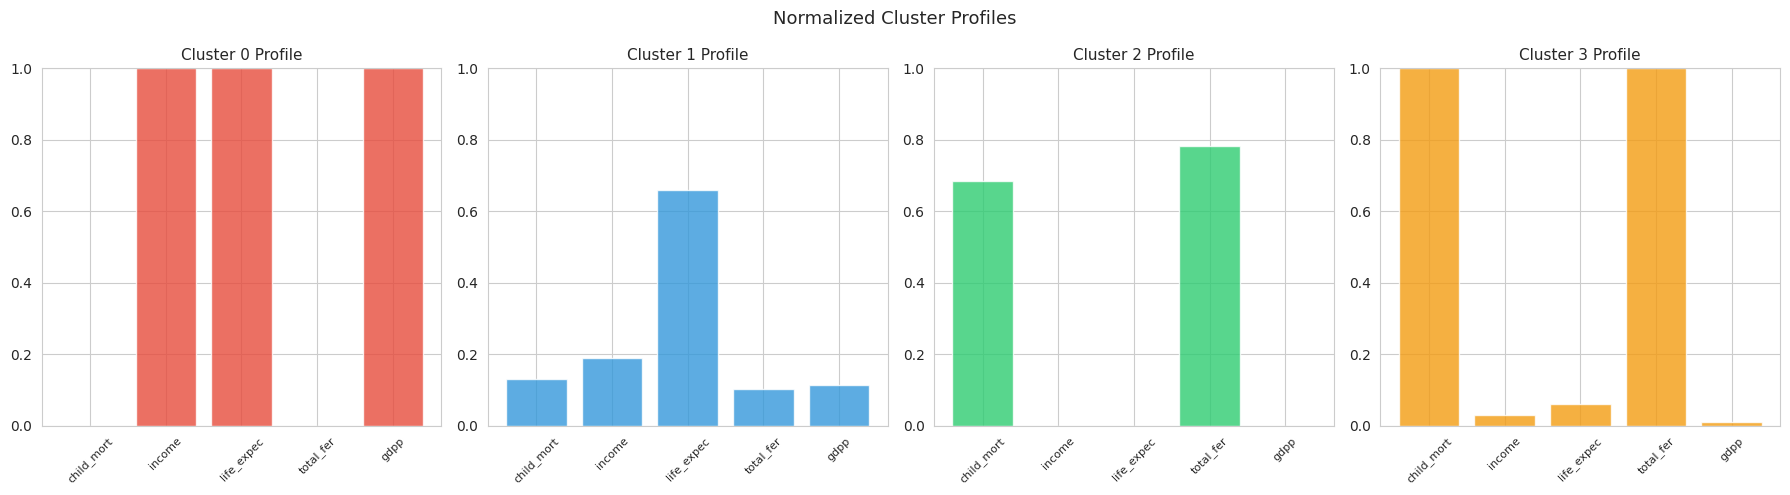

In [38]:
radar_cols = ['child_mort', 'income', 'life_expec', 'total_fer', 'gdpp']
cluster_means = df.groupby('kmeans_cluster')[radar_cols].mean()

cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for cl, ax in zip(sorted(df['kmeans_cluster'].unique()), axes):
    vals = cluster_means_norm.loc[cl].values
    ax.bar(radar_cols, vals, color=colors_cl[cl], edgecolor='white', alpha=0.8)
    ax.set_title(f'Cluster {cl} Profile', fontsize=11)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.suptitle('Normalized Cluster Profiles', fontsize=13)
plt.tight_layout()
plt.show()

In [39]:
print('=== Cluster Interpretations ===')
print()
for cl in sorted(df['kmeans_cluster'].unique()):
    countries = df[df['kmeans_cluster'] == cl]['country'].values
    gdp_avg = df[df['kmeans_cluster'] == cl]['gdpp'].mean()
    print(f'Cluster {cl} | Countries: {len(countries)} | Avg GDP: ${gdp_avg:,.0f}')
    print(f'  Sample: {list(countries[:6])}')
    print()

=== Cluster Interpretations ===

Cluster 0 | Countries: 36 | Avg GDP: $42,556
  Sample: ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada']

Cluster 1 | Countries: 83 | Avg GDP: $6,523
  Sample: ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan']

Cluster 2 | Countries: 47 | Avg GDP: $1,900
  Sample: ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi']

Cluster 3 | Countries: 1 | Avg GDP: $2,330
  Sample: ['Nigeria']



## 13. Final Model Evaluation Summary

In [40]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_score_rf = rf.predict_proba(X_test)
y_score_xgb = xgb.predict_proba(X_test)

roc_rf = roc_auc_score(y_test_bin, y_score_rf, multi_class='ovr')
roc_xgb = roc_auc_score(y_test_bin, y_score_xgb, multi_class='ovr')

print(f'ROC-AUC (Random Forest): {roc_rf:.4f}')
print(f'ROC-AUC (XGBoost):       {roc_xgb:.4f}')

ROC-AUC (Random Forest): 0.9922
ROC-AUC (XGBoost):       0.9967


In [41]:
final_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'Logistic Regression', 'Random Forest', 'XGBoost', 'Gradient Boosting'],
    'Test Accuracy': [
        round(accuracy_score(y_test, y_pred_dt), 4),
        round(accuracy_score(y_test, y_pred_lr), 4),
        round(accuracy_score(y_test, y_pred_rf), 4),
        round(accuracy_score(y_test, y_pred_xgb), 4),
        round(accuracy_score(y_test, y_pred_gb), 4)
    ],
    'Notes': [
        'Baseline — tends to overfit',
        'Stable, interpretable',
        'Best ensemble — stable across folds',
        'Strong gradient boost variant',
        'Tuned via GridSearch'
    ]
})

final_summary

,Model,Test Accuracy,Notes
0,Decision Tree,0.9459,Baseline — tends to overfit
1,Logistic Regression,0.9189,"Stable, interpretable"
2,Random Forest,0.9189,Best ensemble — stable across folds
3,XGBoost,0.9459,Strong gradient boost variant
4,Gradient Boosting,0.8919,Tuned via GridSearch


In [42]:
print('Clustering Summary')
print('===================')
print(f"K-Means (k=4) Silhouette Score : {silhouette_score(X_cluster_scaled, df['kmeans_cluster']):.4f}")
print(f"DBSCAN Clusters Found          : {n_clusters}")
print(f"DBSCAN Noise Points            : {n_noise}")

Clustering Summary
K-Means (k=4) Silhouette Score : 0.4330
DBSCAN Clusters Found          : 1
DBSCAN Noise Points            : 8
